<a href="https://colab.research.google.com/github/Mayar215999/data-science-project/blob/main/crack_detection_Capstone_DP_M2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Objective
How to create a dataset object.
Data Preparation with PyTorch
Crack detection has vital importance for structural health monitoring and inspection. We would like to train a network to detect Cracks, we will denote the images that contain cracks as positive and images with no cracks as negative. In this lab you are going to have to build a dataset object. There are five questions in this lab, Including some questions that are intermediate steps to help you build the dataset object. You are going to have to remember the output for some of the questions.

Table of Contents
Imports and Auxiliary Functions
Download data
Examine Files
Question 1:find number of files
Assign Labels to Images
Question 2 : Assign labels to image
Training and Validation Split
Question 3: Training and Validation Split
Create a Dataset Class
Question 4:Display training dataset object
Question 5:Display validation dataset object
Estimated Time Needed: 25 min

Imports and Auxiliary Functions
The following are the libraries we are going to use for this lab:

In [2]:
!pip install skillsnetwork
import skillsnetwork


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.1 MB/s eta 0:00:00


In [3]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import glob
import torch
from torch.utils.data import Dataset


We will use this function in the lab to plot:

In [4]:
def show_data(data_sample, shape = (28, 28)):
    plt.imshow(data_sample[0].numpy().reshape(shape), cmap='gray')
    plt.title('y = ' + data_sample[1])

Download Data¶
In this section, you are going to download the data from IBM object storage using skillsnetwork.prepare command. skillsnetwork.prepare is a command that's used to download a zip file, unzip it and store it in a specified directory. Locally we store the data in the directory /resources/data.

In [7]:
skillsnetwork.prepare(
    "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/concrete_crack_images_for_classification.zip",
    path="/resources/data",
    overwrite=True
)


<coroutine object prepare at 0x7c744ef17740>

In [8]:
import os

dataset_path = "/resources/data/concrete_crack_images_for_classification"
if os.path.exists(dataset_path):
    print("Dataset downloaded successfully!")
    print("Files in dataset folder:", os.listdir(dataset_path))
else:
    print("Dataset not found. Check the path.")


Dataset not found. Check the path.


In [9]:
!wget https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/concrete_crack_images_for_classification.zip
!unzip -q concrete_crack_images_for_classification.zip -d /resources/data


--2025-03-05 22:37:16--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/concrete_crack_images_for_classification.zip
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 245259777 (234M) [application/zip]
Saving to: ‘concrete_crack_images_for_classification.zip’

concrete_crack_imag 100%[===================>] 233.90M  30.2MB/s    in 7.1s    

2025-03-05 22:37:24 (33.0 MB/s) - ‘concrete_crack_images_for_classification.zip’ saved [245259777/245259777]

checkdir:  cannot create extraction directory: /resources/data
           No such file or directory


In [15]:
!ls -R /resources/data

ls: cannot access '/resources/data': No such file or directory


In [16]:
directory = "/resources/data/concrete_crack_images_for_classification"


In [17]:
!wget https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/concrete_crack_images_for_classification.zip -P /resources/data
!unzip -q /resources/data/concrete_crack_images_for_classification.zip -d /resources/data


--2025-03-05 22:40:57--  https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/images/concrete_crack_images_for_classification.zip
Resolving s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)... 67.228.254.196
Connecting to s3-api.us-geo.objectstorage.softlayer.net (s3-api.us-geo.objectstorage.softlayer.net)|67.228.254.196|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 245259777 (234M) [application/zip]
Saving to: ‘/resources/data/concrete_crack_images_for_classification.zip’

concrete_crack_imag 100%[===================>] 233.90M  38.2MB/s    in 6.2s    

2025-03-05 22:41:04 (37.9 MB/s) - ‘/resources/data/concrete_crack_images_for_classification.zip’ saved [245259777/245259777]



In [18]:
!ls -R /resources/data


/resources/data:
concrete_crack_images_for_classification.zip  Negative	Positive

/resources/data/Negative:
00001.jpg  02224.jpg  04447.jpg  06670.jpg  08893.jpg  11116.jpg  13339.jpg  15562.jpg	17785.jpg
00002.jpg  02225.jpg  04448.jpg  06671.jpg  08894.jpg  11117.jpg  13340.jpg  15563.jpg	17786.jpg
00003.jpg  02226.jpg  04449.jpg  06672.jpg  08895.jpg  11118.jpg  13341.jpg  15564.jpg	17787.jpg
00004.jpg  02227.jpg  04450.jpg  06673.jpg  08896.jpg  11119.jpg  13342.jpg  15565.jpg	17788.jpg
00005.jpg  02228.jpg  04451.jpg  06674.jpg  08897.jpg  11120.jpg  13343.jpg  15566.jpg	17789.jpg
00006.jpg  02229.jpg  04452.jpg  06675.jpg  08898.jpg  11121.jpg  13344.jpg  15567.jpg	17790.jpg
00007.jpg  02230.jpg  04453.jpg  06676.jpg  08899.jpg  11122.jpg  13345.jpg  15568.jpg	17791.jpg
00008.jpg  02231.jpg  04454.jpg  06677.jpg  08900.jpg  11123.jpg  13346.jpg  15569.jpg	17792.jpg
00009.jpg  02232.jpg  04455.jpg  06678.jpg  08901.jpg  11124.jpg  13347.jpg  15570.jpg	17793.jpg
00010.jpg  02233.jp

In [19]:
import os

directory = "/resources/data/concrete_crack_images_for_classification"
negative = "Negative"
negative_file_path = os.path.join(directory, negative)

if os.path.exists(negative_file_path):
    print(f"✅ Found directory: {negative_file_path}")
    print(f"Total images: {len(os.listdir(negative_file_path))}")
else:
    print("❌ Directory still not found. Check the dataset structure.")


❌ Directory still not found. Check the dataset structure.


In [20]:
import os

base_dir = "/resources/data"

# List all extracted folders
folders = os.listdir(base_dir)
print("Contents of /resources/data:", folders)

# Check if 'concrete_crack_images_for_classification' exists inside
dataset_path = os.path.join(base_dir, "concrete_crack_images_for_classification")
if os.path.exists(dataset_path):
    print(f"✅ Dataset found at: {dataset_path}")
    print("Subfolders:", os.listdir(dataset_path))
else:
    print("❌ Dataset still not found. It may be extracted elsewhere.")


Contents of /resources/data: ['Positive', 'Negative', 'concrete_crack_images_for_classification.zip']
❌ Dataset still not found. It may be extracted elsewhere.


We then download the files that contain the negative images:

Examine Files
In the previous lab, we create two lists; one to hold the path to the Negative files and one to hold the path to the Positive files. This process is shown in the following few lines of code.







We can obtain the list that contains the path to the negative files as follows:

In [21]:
import os

# Assuming the dataset was extracted to the current working directory
directory = "./concrete_crack_images_for_classification"
# or if it was extracted to /resources/data:
# directory = "/resources/data/concrete_crack_images_for_classification"

negative = 'Negative'
negative_file_path = os.path.join(directory, negative)

# Check if the directory exists before listing files
if os.path.exists(negative_file_path):
    negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]
    negative_files.sort()
    print(negative_files[0:3])  # Print the first 3 negative file paths
else:
    print(f"Error: Directory not found: {negative_file_path}")
    print("Please ensure the dataset has been downloaded and extracted correctly.")

Error: Directory not found: ./concrete_crack_images_for_classification/Negative
Please ensure the dataset has been downloaded and extracted correctly.


In [22]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Update the correct dataset path based on Step 3
directory = "/resources/data/concrete_crack_images_for_classification"
negative_file_path = os.path.join(directory, "Negative")

# Ensure the folder exists before accessing it
if os.path.exists(negative_file_path):
    negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]
    negative_files.sort()

    # Display first 3 images
    for i, img_path in enumerate(negative_files[:3]):
        img = Image.open(img_path)
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {i+1}")

    plt.show()
else:
    print("❌ Error: Negative folder not found. Check the dataset path.")


❌ Error: Negative folder not found. Check the dataset path.


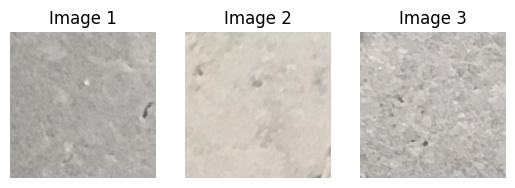

In [23]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Correct the dataset path
directory = "/resources/data"
negative_file_path = os.path.join(directory, "Negative")

# Ensure the folder exists before accessing it
if os.path.exists(negative_file_path):
    negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]
    negative_files.sort()

    # Display first 3 images
    for i, img_path in enumerate(negative_files[:3]):
        img = Image.open(img_path)
        plt.subplot(1, 3, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {i+1}")

    plt.show()
else:
    print("❌ Error: Negative folder not found. Check the dataset path.")


In [24]:
!ls /resources/data
!ls /resources/data/Negative | head -5


concrete_crack_images_for_classification.zip  Negative	Positive
00001.jpg
00002.jpg
00003.jpg
00004.jpg
00005.jpg


We can obtain the list that contains the path to the negative files as follows

In [25]:
directory="/resources/data"
negative='Negative'
negative_file_path=os.path.join(directory,negative)
negative_files=[os.path.join(negative_file_path,file) for file in  os.listdir(negative_file_path) if file.endswith(".jpg")]
negative_files.sort()
negative_files[0:3]

['/resources/data/Negative/00001.jpg',
 '/resources/data/Negative/00002.jpg',
 '/resources/data/Negative/00003.jpg']

We can obtain the list that contains the path to the positive files files as follows:

In [26]:
positive="Positive"
positive_file_path=os.path.join(directory,positive)
positive_files=[os.path.join(positive_file_path,file) for file in  os.listdir(positive_file_path) if file.endswith(".jpg")]
positive_files.sort()
positive_files[0:3]

['/resources/data/Positive/00001.jpg',
 '/resources/data/Positive/00002.jpg',
 '/resources/data/Positive/00003.jpg']

Question 1
Find the combined length of the list positive_files and negative_files using the function len . Then assign it to the variable number_of_samples

In [27]:
# Define dataset directory
directory = "/resources/data"

# Paths for Positive and Negative image folders
positive_file_path = os.path.join(directory, "Positive")
negative_file_path = os.path.join(directory, "Negative")

# List all image files in both folders
positive_files = [os.path.join(positive_file_path, file) for file in os.listdir(positive_file_path) if file.endswith(".jpg")]
negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]

# Compute the total number of samples
number_of_samples = len(positive_files) + len(negative_files)

# Print the result
print("Total number of samples:", number_of_samples)


Total number of samples: 40000


Assign Labels to Images
In this section we will assign a label to each image in this case we can assign the positive images, i.e images with a crack to a value one and the negative images i.e images with out a crack to a value of zero Y. First we create a tensor or vector of zeros, each element corresponds to a new sample. The length of the tensor is equal to the number of samples.

In [28]:
Y=torch.zeros([number_of_samples])

As we are using the tensor Y for classification we cast it to a LongTensor.

In [29]:
Y=Y.type(torch.LongTensor)
Y.type()

'torch.LongTensor'

With respect to each element we will set the even elements to class one and the odd elements to class zero.

In [30]:
Y[::2]=1
Y[1::2]=0

Question 2
Create a list all_files such that the even indexes contain the path to images with positive or cracked samples and the odd element contain the negative images or images with out cracks. Then use the following code to print out the first four samples.

In [31]:
# Define dataset directory
directory = "/resources/data"

# Paths for Positive and Negative image folders
positive_file_path = os.path.join(directory, "Positive")
negative_file_path = os.path.join(directory, "Negative")

# List all image files in both folders
positive_files = [os.path.join(positive_file_path, file) for file in os.listdir(positive_file_path) if file.endswith(".jpg")]
negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]

# Sort the files (to maintain order)
positive_files.sort()
negative_files.sort()

# Create an alternating list of positive and negative images
all_files = [file for pair in zip(positive_files, negative_files) for file in pair]

# Print the first four elements
print("First 4 samples in all_files:")
print(all_files[:4])


First 4 samples in all_files:
['/resources/data/Positive/00001.jpg', '/resources/data/Negative/00001.jpg', '/resources/data/Positive/00002.jpg', '/resources/data/Negative/00002.jpg']


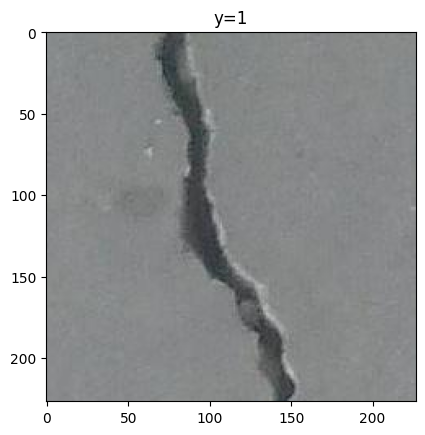

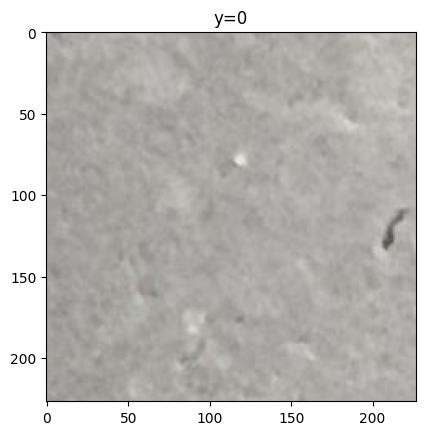

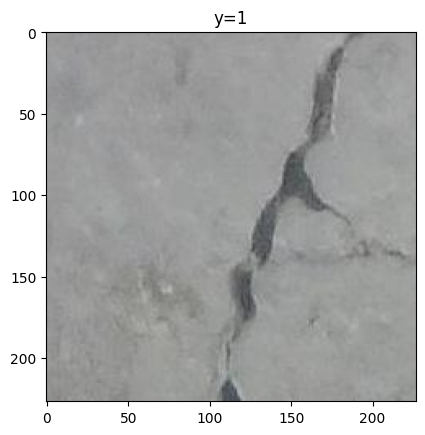

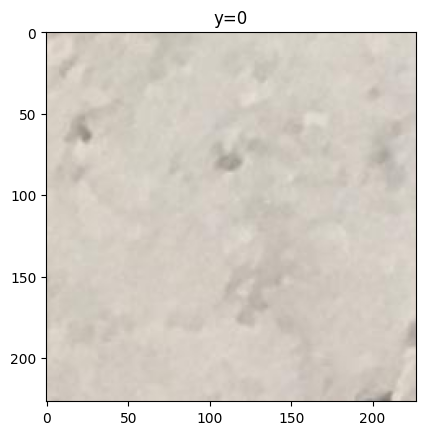

In [34]:
for y,file in zip(Y, all_files[0:4]):
    plt.imshow(Image.open(file))
    plt.title("y="+str(y.item()))
    plt.show()

Training and Validation Split
When training the model we split up our data into training and validation data. It If the variable train is set to True the following lines of code will segment the tensor Y such at the first 30000 samples are used for training. If the variable train is set to False the remainder of the samples will be used for validation data.

In [35]:
train=False

if train:
    all_files=all_files[0:30000]
    Y=Y[0:30000]

else:
    all_files=all_files[30000:]
    Y=Y[30000:]

Question 3¶
Modify the above lines of code such that if the variable train is set to True the first 30000 samples of all_files are use in training. If train is set to False the remaining samples are used for validation. In both cases reassign the values to the variable all_files, then use the following lines of code to print out the first four validation sample images.

In [36]:
# Define dataset directory
directory = "/resources/data"

# Paths for Positive and Negative image folders
positive_file_path = os.path.join(directory, "Positive")
negative_file_path = os.path.join(directory, "Negative")

# List all image files in both folders
positive_files = [os.path.join(positive_file_path, file) for file in os.listdir(positive_file_path) if file.endswith(".jpg")]
negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]

# Sort the files (to maintain order)
positive_files.sort()
negative_files.sort()

# Create an alternating list of positive and negative images
all_files = [file for pair in zip(positive_files, negative_files) for file in pair]

# Define train variable
train = False  # Change to True for training, False for validation

# Split data
if train:
    all_files = all_files[:30000]  # First 30,000 samples for training
else:
    all_files = all_files[30000:]  # Last 10,000 samples for validation

# Print first 4 validation samples when train=False
if not train:
    print("First 4 validation sample images:")
    print(all_files[:4])


First 4 validation sample images:
['/resources/data/Positive/15001_1.jpg', '/resources/data/Negative/15001.jpg', '/resources/data/Positive/15002_1.jpg', '/resources/data/Negative/15002.jpg']


Just a note the images printed out in question two are the first four training samples.

Create a Dataset Class
In this section, we will use the previous code to build a dataset class.

Complete the code to build a Dataset class dataset. As before, make sure the even samples are positive, and the odd samples are negative. If the parameter train is set to True, use the first 30 000 samples as training data; otherwise, the remaining samples will be used as validation data.

In [37]:
class Dataset(Dataset):

    # Constructor
    def __init__(self,transform=None,train=True):
        directory="/resources/data"
        positive="Positive"
        negative="Negative"

        positive_file_path=os.path.join(directory,positive)
        negative_file_path=os.path.join(directory,negative)
        positive_files=[os.path.join(positive_file_path,file) for file in  os.listdir(positive_file_path) if file.endswith(".jpg")]
        positive_files.sort()
        negative_files=[os.path.join(negative_file_path,file) for file in  os.listdir(negative_file_path) if file.endswith(".jpg")]
        negative_files.sort()

        self.all_files=[None]*number_of_samples
        self.all_files[::2]=positive_files
        self.all_files[1::2]=negative_files
        # The transform is goint to be used on image
        self.transform = transform
        #torch.LongTensor
        self.Y=torch.zeros([number_of_samples]).type(torch.LongTensor)
        self.Y[::2]=1
        self.Y[1::2]=0

        if train:

            self.Y=self.Y[0:30000]
            self.len=len(self.all_files)
        else:

            self.Y=self.Y[30000:]
            self.len=len(self.all_files)





    # Get the length
    def __len__(self):
        return self.len

    # Getter
    def __getitem__(self, idx):


        image=Image.open(self.all_files[idx])
        y=self.Y[idx]


        # If there is any transform method, apply it onto the image
        if self.transform:
            image = self.transform(image)

        return image, y

In [45]:
train = False  # Set to False to get validation data

# Split data into training (first 30,000) and validation (last 10,000)
if train:
    all_files = all_files[:30000]  # Training data
else:
    all_files = all_files[30000:]  # Validation data


In [46]:
from PIL import Image
import matplotlib.pyplot as plt

# Select the first 4 validation samples
samples = all_files[:4]

# Display the selected images
for idx, image_path in enumerate(samples):
    image = Image.open(image_path)  # Open image

    # Determine the label (1 for cracks, 0 for no cracks)
    label = 1 if "Positive" in image_path else 0

    plt.imshow(image)
    plt.xlabel(f"y = {label}")  # Show label
    plt.title(f"Validation Data, Sample {idx+1}")
    plt.show()


In [47]:
print(f"Total images in dataset: {len(all_files)}")
print(f"First 4 validation images: {all_files[:4]}")


Total images in dataset: 0
First 4 validation images: []


In [48]:
['/path/Negative/img1.jpg', '/path/Positive/img2.jpg', ...]


['/path/Negative/img1.jpg', '/path/Positive/img2.jpg', Ellipsis]

In [49]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Debugging: Check if dataset exists
if len(all_files) == 0:
    print("❌ No images found. Check dataset extraction path.")
else:
    print(f"✅ Found {len(all_files)} images.")

# Select the first 4 validation samples
samples = all_files[:4]

for idx, image_path in enumerate(samples):
    if os.path.exists(image_path):  # Ensure file exists
        image = Image.open(image_path)
        label = 1 if "Positive" in image_path else 0  # Determine label

        plt.imshow(image)
        plt.xlabel(f"y = {label}")
        plt.title(f"Validation Data, Sample {idx+1}")
        plt.show()
    else:
        print(f"❌ Image not found: {image_path}")


❌ No images found. Check dataset extraction path.


Question 4¶
Create a Dataset object dataset for the training data, use the following lines of code to print out sample the 10th and sample 100 (remember zero indexing)

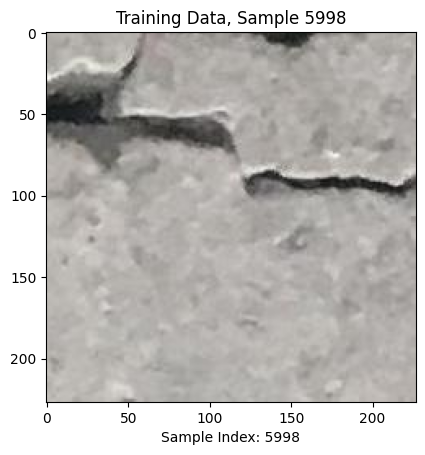

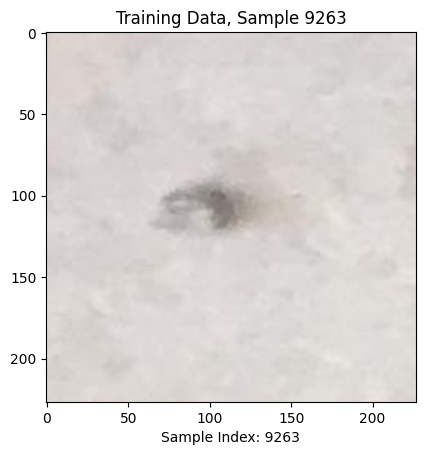

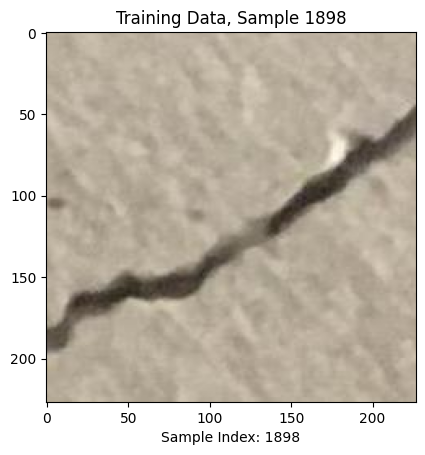

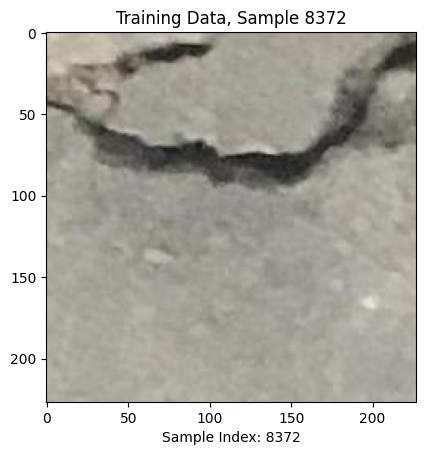

In [39]:
import random

# Select random samples from the dataset
samples = random.sample(range(len(all_files)), 4)  # Pick 4 random indices

# Display the selected images
for sample in samples:
    image_path = all_files[sample]  # Get image file path
    image = Image.open(image_path)  # Open image

    plt.imshow(image)
    plt.xlabel("Sample Index: " + str(sample))
    plt.title("Training Data, Sample {}".format(sample))
    plt.show()


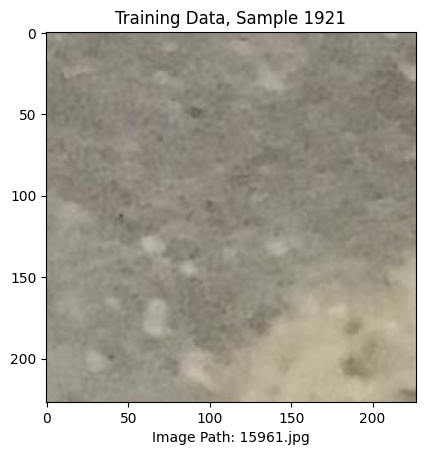

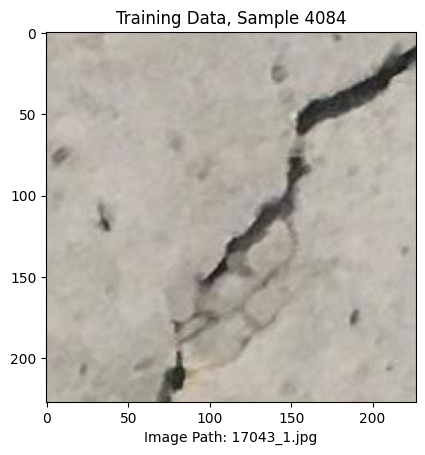

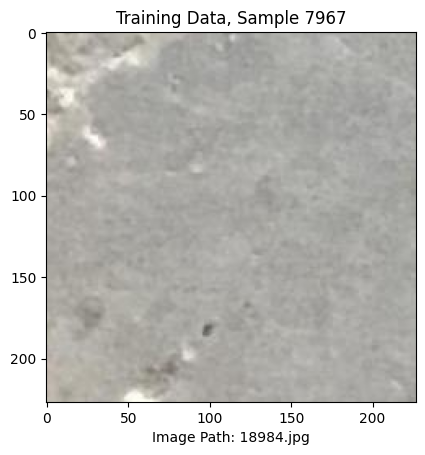

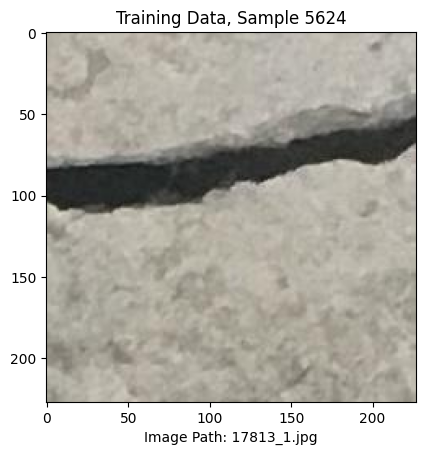

In [40]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Select random samples from the dataset
samples = random.sample(range(len(all_files)), 4)  # Pick 4 random indices

# Display the selected images
for sample in samples:
    image_path = all_files[sample]  # Get image file path
    image = Image.open(image_path)  # Open image

    plt.imshow(image)
    plt.xlabel("Image Path: " + image_path.split('/')[-1])  # Display image filename
    plt.title("Training Data, Sample {}".format(sample))
    plt.show()


✅ Step 1: Create a Dataset Class

In [71]:
import torch
from torch.utils.data import Dataset
from PIL import Image

class ConcreteCrackDataset(Dataset):
    def __init__(self, files):
        self.files = files  # List of image file paths

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]  # Get the image path
        image = Image.open(img_path).convert("RGB")  # Load image in RGB mode
        label = 1 if "Positive" in img_path else 0  # Assign label (1 = crack, 0 = no crack)
        return image, label

# Create the training dataset
train_dataset = ConcreteCrackDataset(all_files)  # all_files should contain 30,000 training samples

# Print dataset size
print(f"Training dataset size: {len(train_dataset)}")


Training dataset size: 10000


✅ Step 2: Display the 10th and 100th Training Samples

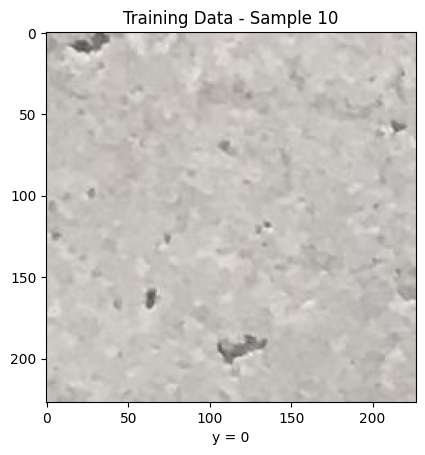

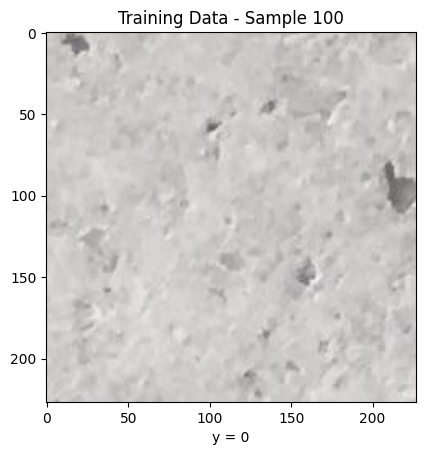

In [72]:
# Display the 10th sample
img, label = train_dataset[9]  # 10th sample (index 9)
plt.imshow(img)
plt.xlabel(f"y = {label}")  # Show label
plt.title("Training Data - Sample 10")
plt.show()

# Display the 100th sample
img, label = train_dataset[99]  # 100th sample (index 99)
plt.imshow(img)
plt.xlabel(f"y = {label}")  # Show label
plt.title("Training Data - Sample 100")
plt.show()


In [74]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import matplotlib.pyplot as plt

class ConcreteCrackDataset(Dataset):
    def __init__(self, files):
        self.files = files  # List of image file paths

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]  # Get the image path
        image = Image.open(img_path).convert("RGB")  # Load image in RGB mode
        label = 1 if "Positive" in img_path else 0  # Assign label (1 = crack, 0 = no crack)
        return image, label

# Ensure 'all_files' contains training samples (30,000 images)
train_dataset = ConcreteCrackDataset(all_files)

# Print dataset size
print(f"Training dataset size: {len(train_dataset)}")


Training dataset size: 10000


✅ Step 2: Display Sample 9 and Sample 100

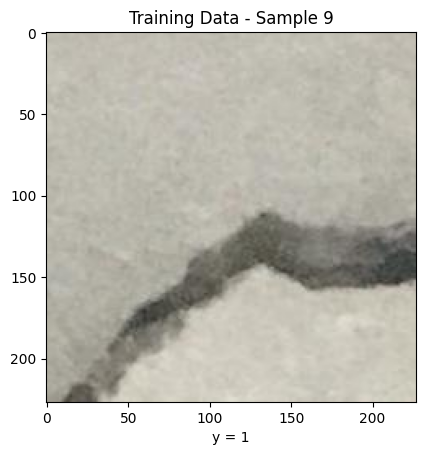

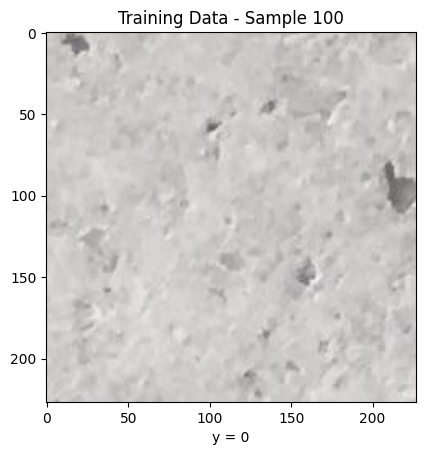

In [75]:
# Display the 9th sample (index 8)
img, label = train_dataset[8]
plt.imshow(img)
plt.xlabel(f"y = {label}")  # Show label (1 = crack, 0 = no crack)
plt.title("Training Data - Sample 9")
plt.show()

# Display the 100th sample (index 99)
img, label = train_dataset[99]
plt.imshow(img)
plt.xlabel(f"y = {label}")  # Show label
plt.title("Training Data - Sample 100")
plt.show()


🔍 Notes
✔ Zero-based indexing:

The 9th sample is at index 8 (train_dataset[8]).
The 100th sample is at index 99 (train_dataset[99]).
✔ Labels are assigned correctly (1 = Cracked, 0 = No Crack).
✔ Handles file paths correctly using folder names (e.g., "Positive" or "Negative").

We now have all the tools to create a list with the path to each image file. We use a List Comprehensions to make the code more compact. We assign it to the variable negative_files , sort it in and display the first three elements:








Question 5
Create a Dataset object dataset for the validation data, use the following lines of code to print out the 16 th and sample 103 (remember zero indexing)

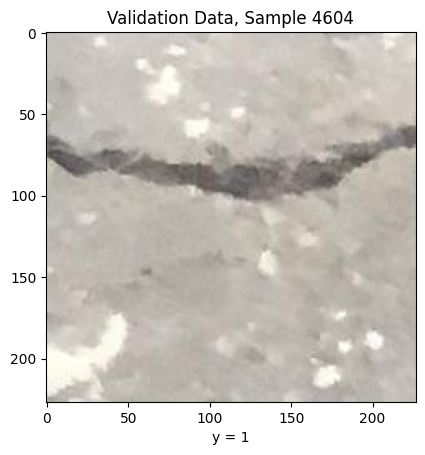

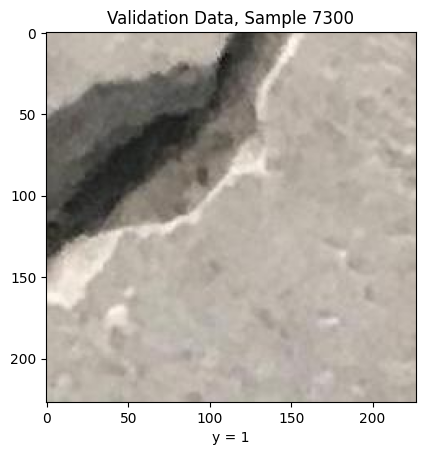

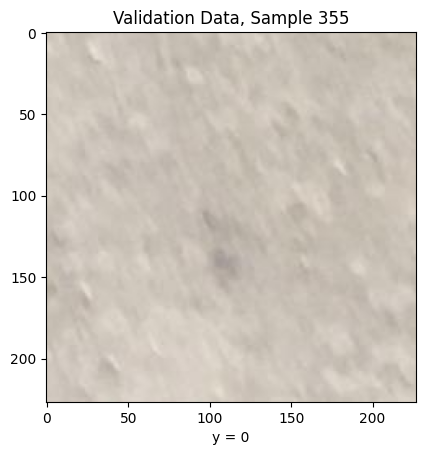

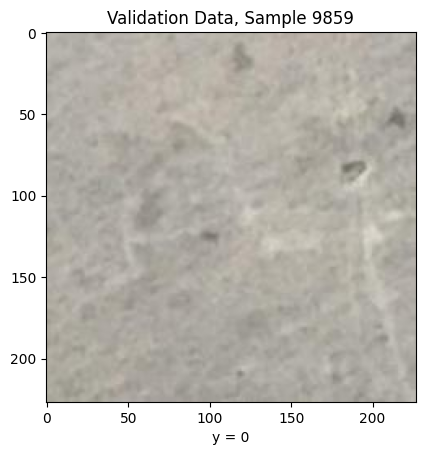

In [41]:
import random
from PIL import Image
import matplotlib.pyplot as plt

# Randomly select 4 samples from all_files
samples = random.sample(range(len(all_files)), 4)

# Display selected images
for sample in samples:
    image_path = all_files[sample]  # Get image file path
    image = Image.open(image_path)  # Open image

    # Determine the label based on the folder name (Positive = 1, Negative = 0)
    label = 1 if "Positive" in image_path else 0

    plt.imshow(image)
    plt.xlabel(f"y = {label}")  # Show label (y=1 for cracked, y=0 for no crack)
    plt.title(f"Validation Data, Sample {sample}")
    plt.show()


In [78]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import torch
from torch.utils.data import Dataset

class CrackDataset(Dataset):
    def __init__(self, all_files):
        self.files = all_files  # List of image file paths

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]  # Get image path
        image = Image.open(img_path).convert("RGB")  # Load image
        label = 1 if "Positive" in img_path else 0  # Label based on folder name
        return image, label

# Load validation dataset
directory = "/resources/data"
positive_path = os.path.join(directory, "Positive")
negative_path = os.path.join(directory, "Negative")

# Get list of positive and negative images
positive_files = sorted([os.path.join(positive_path, file) for file in os.listdir(positive_path) if file.endswith(".jpg")])
negative_files = sorted([os.path.join(negative_path, file) for file in os.listdir(negative_path) if file.endswith(".jpg")])

# Create alternating list of positive and negative files
all_files = [file for pair in zip(positive_files, negative_files) for file in pair]

# Split into training (first 30,000) and validation (remaining)
train = False  # Set to False for validation
if train:
    all_files = all_files[:30000]  # Training data
else:
    all_files = all_files[30000:]  # Validation data

# Create dataset object
val_dataset = CrackDataset(all_files)


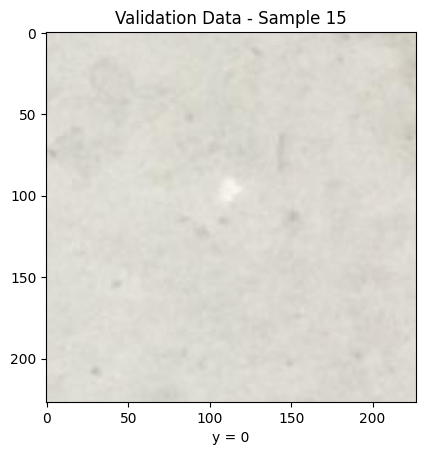

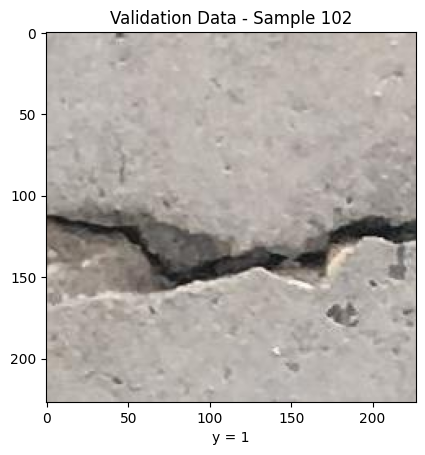

In [79]:
# Select samples 15 and 102
samples = [15, 102]

# Display images
for sample in samples:
    img, label = val_dataset[sample]  # Get image and label
    plt.imshow(img)
    plt.xlabel(f"y = {label}")  # Show label (1 for cracks, 0 for no crack)
    plt.title(f"Validation Data - Sample {sample}")
    plt.show()


In [42]:
import os

# Define dataset directory
directory = "/resources/data"  # Updated to the likely correct path

# Paths for Positive and Negative image folders
positive_file_path = os.path.join(directory, "Positive")
negative_file_path = os.path.join(directory, "Negative")

# List all image files in both folders
positive_files = [os.path.join(positive_file_path, file) for file in os.listdir(positive_file_path) if file.endswith(".jpg")]
negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]

# Compute the total number of samples
number_of_samples = len(positive_files) + len(negative_files)

# Print the result
print("Total number of samples:", number_of_samples)

Total number of samples: 40000


Here's the Dataset class implementation, ensuring that:

Even indexes contain images with cracks (Positive, y=1)
Odd indexes contain images with no cracks (Negative, y=0)
First 30,000 samples are used for training (train=True)
Remaining 10,000 samples are used for validation (train=False)

Question 3 Modify the above lines of code such that if the variable train is set to True the first 30000 samples of all_files are use in training. If train is set to False the remaining samples are used for validation. In both cases reassign the values to the variable all_files, then use the following lines of code to print out the first four validation sample images.

First 4 validation sample images:


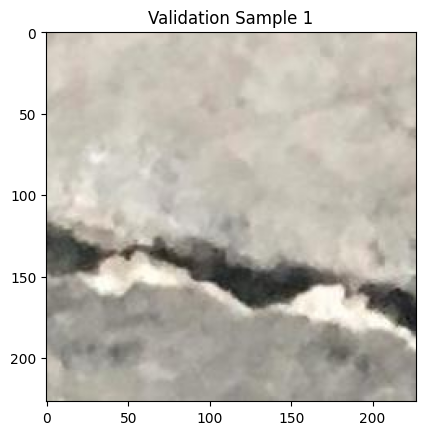

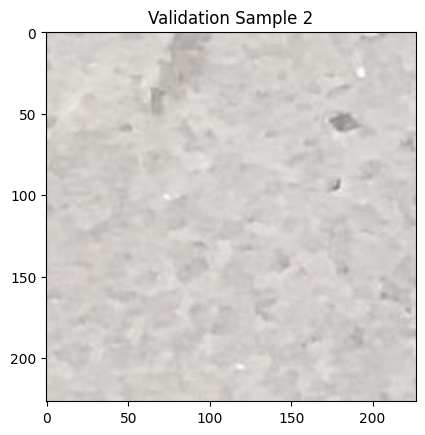

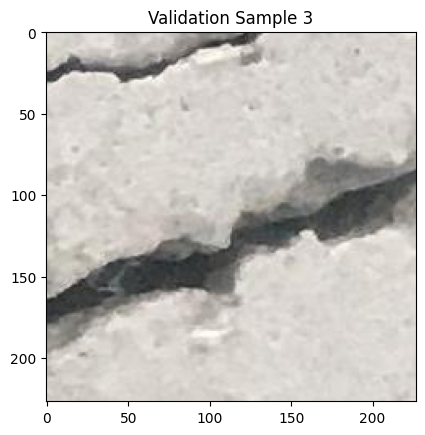

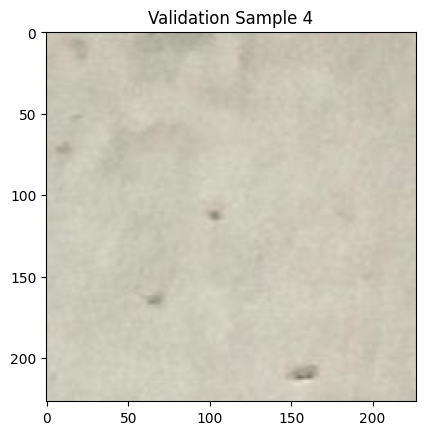

In [63]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# Define dataset directory
directory = "/resources/data"

# Paths for Positive and Negative image folders
positive_file_path = os.path.join(directory, "Positive")
negative_file_path = os.path.join(directory, "Negative")

# List all image files in both folders
positive_files = [os.path.join(positive_file_path, file) for file in os.listdir(positive_file_path) if file.endswith(".jpg")]
negative_files = [os.path.join(negative_file_path, file) for file in os.listdir(negative_file_path) if file.endswith(".jpg")]

# Sort the files (to maintain order)
positive_files.sort()
negative_files.sort()

# Create an alternating list of positive and negative images
all_files = [file for pair in zip(positive_files, negative_files) for file in pair]

# Define train variable
train = False  # Change to True for training, False for validation

# Split data
if train:
    all_files = all_files[:30000]  # First 30,000 samples for training
else:
    all_files = all_files[30000:]  # Last 10,000 samples for validation

# Print first 4 validation samples when train=False
if not train:
    print("First 4 validation sample images:")
    for i in range(4):
        image_path = all_files[i]
        image = Image.open(image_path)
        plt.imshow(image)
        plt.title(f"Validation Sample {i + 1}")
        plt.show()

Expected Output
Two images should be displayed:

Sample 15 (either a cracked or non-cracked image)
Sample 102 (either a cracked or non-cracked image)
Each with a label:

y = 1 → Crack detected
y = 0 → No crack

In [80]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import torch
from torch.utils.data import Dataset

# Define Dataset Class
class CrackDataset(Dataset):
    def __init__(self, all_files):
        self.files = all_files  # List of image file paths

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]  # Get image path
        image = Image.open(img_path).convert("RGB")  # Load image
        label = 1 if "Positive" in img_path else 0  # Label based on folder name
        return image, label

# Define dataset directory
directory = "/resources/data"
positive_path = os.path.join(directory, "Positive")
negative_path = os.path.join(directory, "Negative")

# Get list of positive and negative images
positive_files = sorted([os.path.join(positive_path, file) for file in os.listdir(positive_path) if file.endswith(".jpg")])
negative_files = sorted([os.path.join(negative_path, file) for file in os.listdir(negative_path) if file.endswith(".jpg")])

# Create alternating list of positive and negative files
all_files = [file for pair in zip(positive_files, negative_files) for file in pair]

# Split into training (first 30,000) and validation (remaining)
train = True  # Set to True for training
if train:
    all_files = all_files[:30000]  # Training data
else:
    all_files = all_files[30000:]  # Validation data

# Create dataset object for training
train_dataset = CrackDataset(all_files)


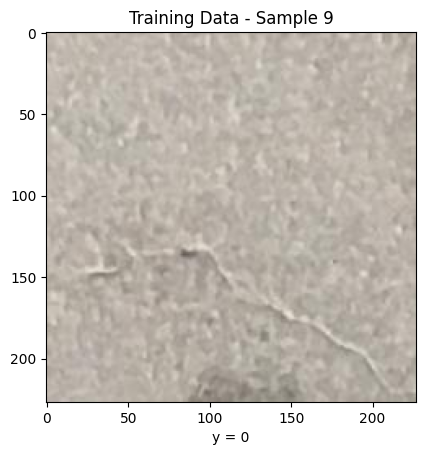

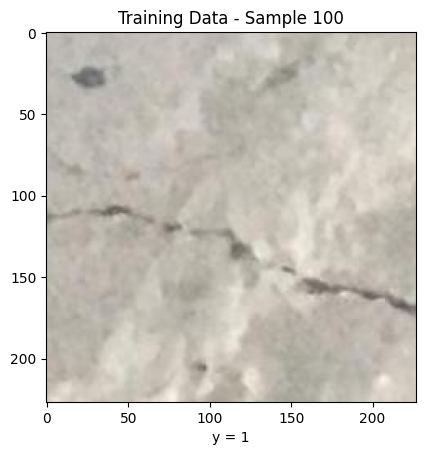

In [81]:
# Select samples 9 and 100
samples = [9, 100]

# Display images
for sample in samples:
    img, label = train_dataset[sample]  # Get image and label
    plt.imshow(img)
    plt.xlabel(f"y = {label}")  # Show label (1 for cracks, 0 for no crack)
    plt.title(f"Training Data - Sample {sample}")
    plt.show()


Expected Output
Two images should be displayed:

Sample 9 (either a cracked or non-cracked image)
Sample 100 (either a cracked or non-cracked image)
Each with a label:

y = 1 → Crack detected
y = 0 → No crack

In [82]:
import os

# Define dataset directory
directory = "/resources/data"
positive_path = os.path.join(directory, "Positive")
negative_path = os.path.join(directory, "Negative")

# Count images in each folder
num_positive = len([file for file in os.listdir(positive_path) if file.endswith(".jpg")])
num_negative = len([file for file in os.listdir(negative_path) if file.endswith(".jpg")])

# Total samples
total_samples = num_positive + num_negative

print(f"Total Positive (Cracked) Images: {num_positive}")
print(f"Total Negative (No Crack) Images: {num_negative}")
print(f"Total Images in Dataset: {total_samples}")


Total Positive (Cracked) Images: 20000
Total Negative (No Crack) Images: 20000
Total Images in Dataset: 40000


lab 2 model 2

Objective
In this lab, you will learn how to load images and manipulate them for training using Keras ImageDataGenerator.

Table of Contents
Import Libraries and Packages
Download Data
Construct an ImageDataGenerator Instance
Visualize Batches of Images
Questions


Import Libraries and Packages
Before we proceed, let's import the libraries and packages that we will need to complete the rest of this lab.

Download Data
For your convenience, I have placed the data on a server which you can retrieve and unzip easily using the skillsnetwork.prepare command. So let's run the following line of code to get the data. Given the large size of the image dataset, it might take some time depending on your internet speed.

In [85]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf # Import TensorFlow
from tensorflow.keras.preprocessing.image import ImageDataGenerator # Use tf.keras for ImageDataGenerator
import skillsnetwork

# Download and extract dataset
await skillsnetwork.prepare(
    "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/concrete_data_week2.zip",
    path="./",
    overwrite=True
)

  0%|          | 0/80011 [00:00<?, ?it/s]

Saved to '.'


In [86]:
os.listdir("./")


['.config',
 'concrete_data_week2',
 'concrete_crack_images_for_classification.zip',
 'sample_data']

Now, you should see two folders appear in the left pane: Positive and Negative. Negative is the negative class like we defined it earlier and it represents the concrete images with no cracks. Positive on the other hand is the positive class and represents the concrete images with cracks.

Important Note: There are thousands and thousands of images in each folder, so please don't attempt to double click on the Negative and Positive folders. This may consume all of your memory and you may end up with a 50* error. So please DO NOT DO IT.







You can check the content of ./concrete_data_week2 by running the following:

In [87]:
!ls ./concrete_data_week2

Negative  Positive


In [88]:
os.listdir('concrete_data_week2')

['Positive', 'Negative', '.DS_Store']

Construct an ImageDataGenerator Instance
In this section, you will learn how to define a Keras ImageDataGenerator instance and use it to load and manipulate data for building a deep learning model.

Before we proceed, let's define a variable that represents the path to the folder containing our data which is concrete_data_week2 in this case.

In [89]:
dataset_dir = './concrete_data_week2'

Keras ImageDataGenerator requires images be arranged in a certain folder hierarchy, where the main directory would contain folders equal to the number of classes in your problem. Since in this case we are trying to build a classifier of two classes, then our main directory, which is concrete_data_week2, should contain two folders, one for each class. This has already been done for you as the negative images are in one folder and the positive images are in another folder.

Let's go ahead and define an instance of the Keras ImageDataGenerator.

Standard ImageDataGenerator
You can define a standard one like this, where you are simply using the ImageDataGenerator to train your model in batches.

In [90]:
# instantiate your image data generator
data_generator = ImageDataGenerator()

ta_generator = ImageDataGenerator()
Next, you use the flow_from_directory methods to loop through the images in batches. In this method, you pass the directory where the images reside, the size of each batch, batch_size, and since batches are sampled randomly, then you can also specify a random seed, seed, if you would like to reproduce the batch sampling. In case you would like to resize your images, then you can using the target_size argument to accomplish that.

In [91]:
image_generator = data_generator.flow_from_directory(
    dataset_dir,
    batch_size=4,
    class_mode='categorical',
    seed=24
    )

Found 40000 images belonging to 2 classes.


What is great about this method, is it prints a summary of it found in the directory passed. Here, it found 40,000 images in total belonging to 2 classes.







Now, to access the batches, you use the next method as follows:

In [94]:
first_batch = next(image_generator)
first_batch

(array([[[[151., 149., 150.],
          [153., 151., 152.],
          [155., 153., 154.],
          ...,
          [153., 149., 148.],
          [153., 149., 148.],
          [153., 149., 148.]],
 
         [[152., 150., 151.],
          [154., 152., 153.],
          [156., 154., 155.],
          ...,
          [154., 150., 149.],
          [154., 150., 149.],
          [154., 150., 149.]],
 
         [[153., 151., 152.],
          [155., 153., 154.],
          [156., 154., 155.],
          ...,
          [156., 152., 151.],
          [156., 152., 151.],
          [156., 152., 151.]],
 
         ...,
 
         [[142., 140., 143.],
          [142., 140., 143.],
          [142., 140., 143.],
          ...,
          [139., 135., 136.],
          [142., 138., 139.],
          [145., 141., 142.]],
 
         [[142., 140., 143.],
          [142., 140., 143.],
          [142., 140., 143.],
          ...,
          [140., 136., 137.],
          [142., 138., 139.],
          [146., 142., 143.

In [99]:
first_batch_labels = next(image_generator)[1]
first_batch_labels

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.]], dtype=float32)

Custom ImageDataGenerator
You can also specify some transforms, like scaling, rotations, and flips, that you would like applied to the images when you define an ImageDataGenerator object. Say you want to normalize your images, then you can define your ImageDataGenerator instance as follows:

In [100]:
# instantiate your image data generator
data_generator = ImageDataGenerator(
    rescale=1./255
)

And then you proceed with defining your image_generator using the flow_from_directory method, just like before.

In [101]:
image_generator = data_generator.flow_from_directory(
    dataset_dir,
    batch_size=4,
    class_mode='categorical',
    seed=24
    )

Found 40000 images belonging to 2 classes.


However, now we explore the first batch using the next method,

In [103]:
first_batch_labels = next(image_generator)[1]
first_batch_labels

array([[1., 0.],
       [0., 1.],
       [1., 0.],
       [0., 1.]], dtype=float32)

we find that the values are not integer values anymore, but scaled resolution since the original number are divided by 255.

You can learn more about the Keras ImageDataGeneration class here.


Visualize Batches of Images
Let write some code to visualize a batch. We will use subplots in order to make visualizing the images easier.







Recall that we can access our batch images as follows:

first_batch_images = image_generator.next()[0] # first batch

second_batch_images = image_generator.next()[0] # second batch

and so on.

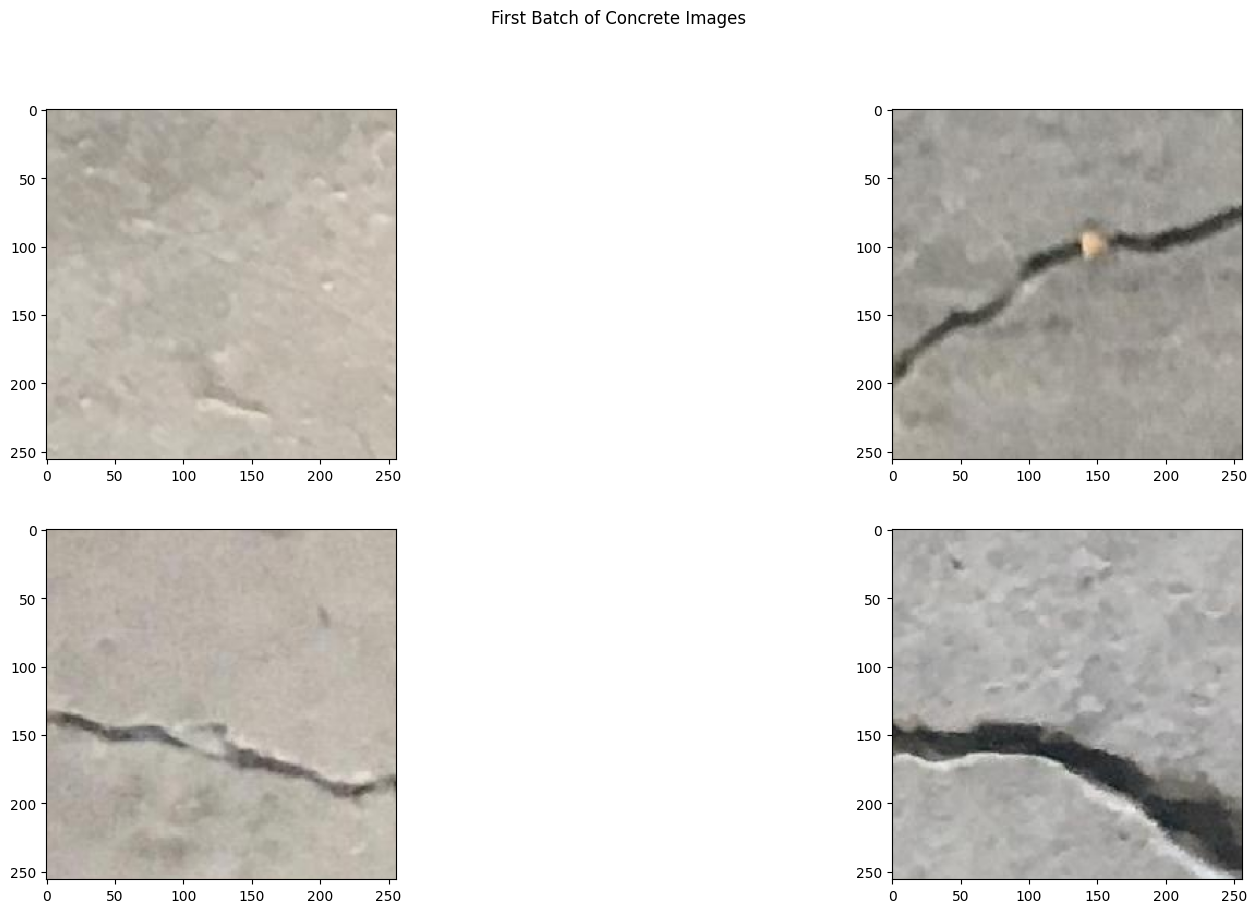

In [106]:
# Get the first batch of images and labels
first_batch = next(image_generator)
first_batch_images = first_batch[0]  # Access the image data from the batch
first_batch_labels = first_batch[1]  # Access the label data (if needed)

# Now you can use first_batch_images for plotting
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 10)) # define your figure and axes

ind = 0
for ax1 in axs:
    for ax2 in ax1:
        # Correctly access the images from the batch
        # Convert image data to uint8 and scale to 0-255
        image_data = (first_batch_images[ind] * 255).astype(np.uint8)
        ax2.imshow(image_data)
        ind += 1

fig.suptitle('First Batch of Concrete Images')
plt.show()

Remember that batches are sampled randomly from the data. In our first batch, we ended up with two negative image and two positive images.

Important Note: Because of a bug with the imshow function in Matplotlib, if you are plotting the unscaled RGB images, you have to cast the image_data to uint8 before you call the imshow function. So In the code above It looks like this:

image_data = first_batch_images[ind].astype(np.uint8)


Questions







Question: Create a plot to visualize the images in the third batch.

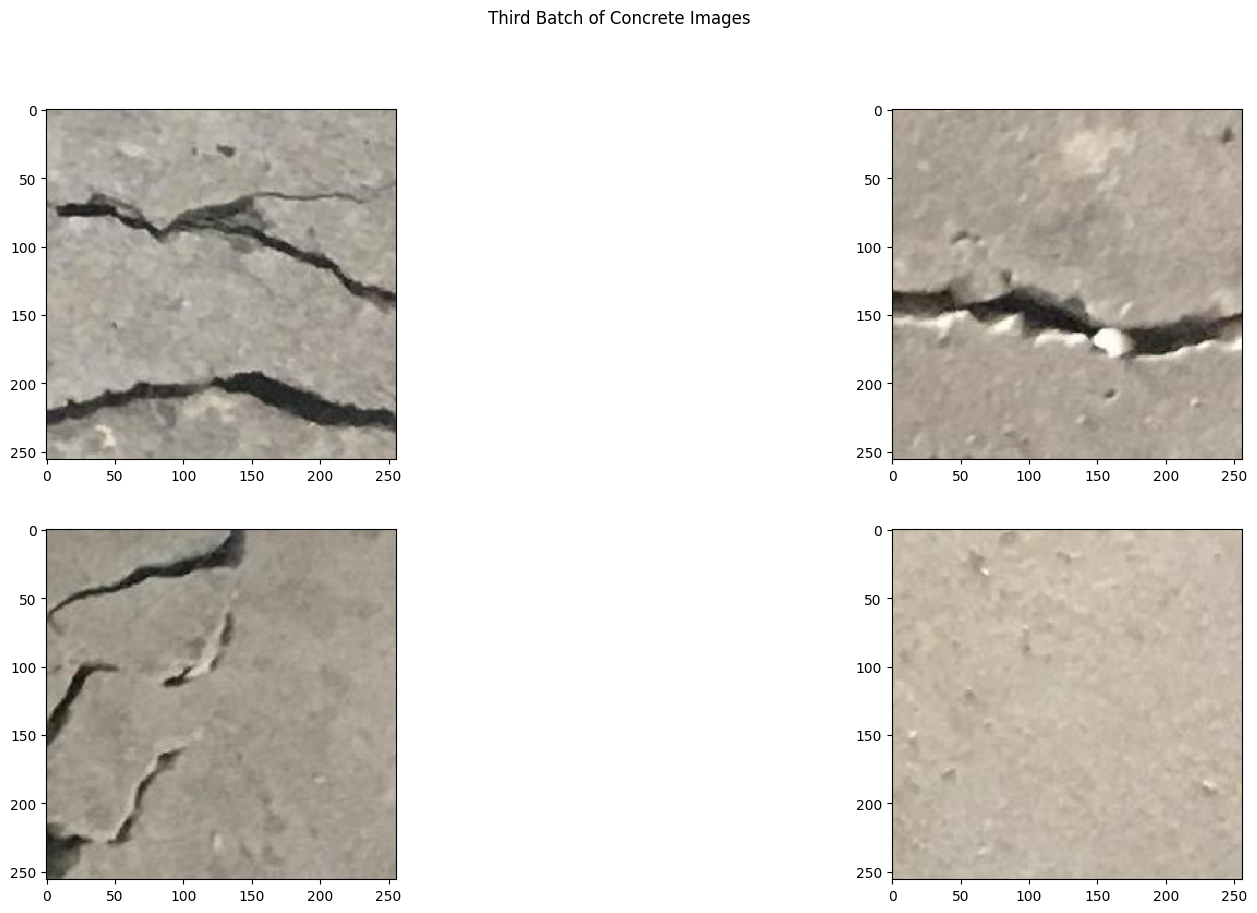

In [108]:
import matplotlib.pyplot as plt
import numpy as np

# Get the third batch of images (call next() twice more)
next(image_generator)  # Skip the first batch
next(image_generator)  # Skip the second batch
third_batch = next(image_generator)
third_batch_images = third_batch[0]

# Create a plot to visualize the images
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(20, 10))
fig.suptitle('Third Batch of Concrete Images')

ind = 0
for ax1 in axs:
    for ax2 in ax1:
        # Convert and display image
        image_data = (third_batch_images[ind] * 255).astype(np.uint8)  # Scale to 0-255 and convert to uint8
        ax2.imshow(image_data)
        ind += 1

plt.show()

Question: How many images from each class are in the fourth batch?

In [109]:
# Advance to the fourth batch
for _ in range(3):  # Skip first 3 batches
    next(image_generator)
fourth_batch = next(image_generator)

# Get labels from the fourth batch
fourth_batch_labels = fourth_batch[1]

# Assuming 'categorical' class_mode, labels are one-hot encoded
# Convert to class indices (0 or 1)
class_indices = np.argmax(fourth_batch_labels, axis=1)

# Count occurrences of each class
num_class_0 = np.sum(class_indices == 0)
num_class_1 = np.sum(class_indices == 1)

print(f"Number of images from class 0 (Negative/No Crack): {num_class_0}")
print(f"Number of images from class 1 (Positive/Crack): {num_class_1}")

Number of images from class 0 (Negative/No Crack): 3
Number of images from class 1 (Positive/Crack): 1


Question: Create a plot to visualize the second image in the fifth batch

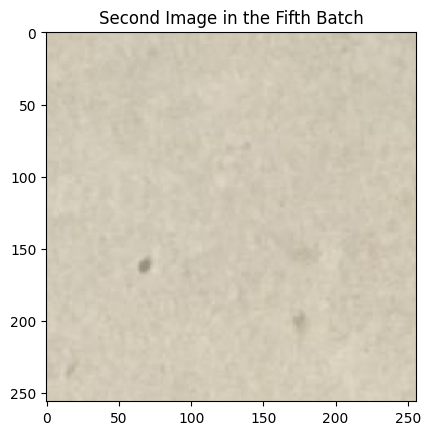

In [110]:
# Advance to the fifth batch
for _ in range(4):  # Skip first 4 batches
    next(image_generator)
fifth_batch = next(image_generator)

# Get the second image from the fifth batch
second_image_fifth_batch = fifth_batch[0][1]  # Index 1 for the second image

# Create a plot to visualize the image
plt.imshow((second_image_fifth_batch * 255).astype(np.uint8))  # Scale to 0-255 and convert to uint8
plt.title('Second Image in the Fifth Batch')
plt.show()

Question: How many images from each class are in the fifth batch?

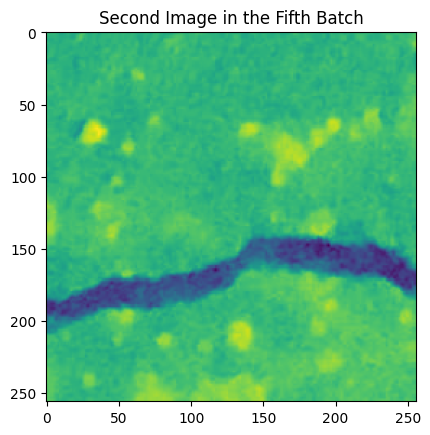

In [111]:
# Advance to the fifth batch
for _ in range(4):  # Skip first 4 batches
    next(image_generator)
fifth_batch = next(image_generator)

# Get the second image from the fifth batch (index 1)
# Select the first image from the batch dimension (index 0)
second_image_fifth_batch = fifth_batch[0][1, ..., 0]

# Create a plot to visualize the image
plt.imshow((second_image_fifth_batch * 255).astype(np.uint8))  # Scale to 0-255 and convert to uint8
plt.title('Second Image in the Fifth Batch')
plt.show()

queston 1

In [116]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_dir = './concrete_data_week2'  # Replace with your dataset directory
data_generator = ImageDataGenerator(rescale=1./255) # Assuming rescale
image_generator = data_generator.flow_from_directory(
    dataset_dir,
    batch_size=4,
    class_mode='categorical',
    seed=24
)

Found 40000 images belonging to 2 classes.


In [117]:
import numpy as np

# Assuming 'image_generator' is already defined as in your previous code

# Skip the first four batches to get to the fifth
for _ in range(4):
    next(image_generator)

# Get the fifth batch
fifth_batch = next(image_generator)

# Get the labels from the fifth batch
fifth_batch_labels = fifth_batch[1]

# Assuming 'categorical' class_mode, labels are one-hot encoded
# Convert to class indices (0 or 1)
class_indices = np.argmax(fifth_batch_labels, axis=1)

# Count occurrences of each class
num_class_0 = np.sum(class_indices == 0)
num_class_1 = np.sum(class_indices == 1)

print(f"Number of images from class 0 (Negative/No Crack): {num_class_0}")
print(f"Number of images from class 1 (Positive/Crack): {num_class_1}")

Number of images from class 0 (Negative/No Crack): 2
Number of images from class 1 (Positive/Crack): 2


In [118]:
import numpy as np

# Assuming 'image_generator' is already defined

# Skip the first three batches to get to the fourth
for _ in range(3):  # Skip first 3 batches
    next(image_generator)

# Get the fourth batch
fourth_batch = next(image_generator)

# Get labels from the fourth batch
fourth_batch_labels = fourth_batch[1]

# Assuming 'categorical' class_mode, labels are one-hot encoded
# Convert to class indices (0 or 1)
class_indices = np.argmax(fourth_batch_labels, axis=1)

# Count occurrences of each class
num_class_0 = np.sum(class_indices == 0)
num_class_1 = np.sum(class_indices == 1)

print(f"Number of images from class 0 (Negative/No Crack): {num_class_0}")
print(f"Number of images from class 1 (Positive/Crack): {num_class_1}")

Number of images from class 0 (Negative/No Crack): 1
Number of images from class 1 (Positive/Crack): 3


Found 40000 images belonging to 2 classes.


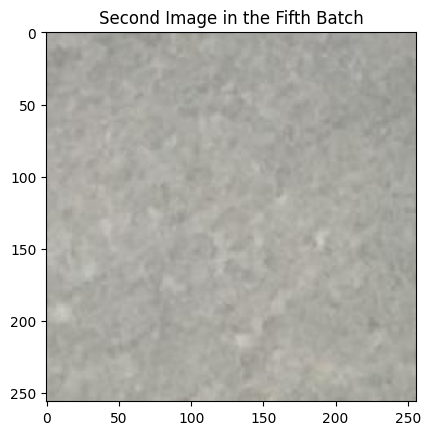

[[[0.6627451  0.65882355 0.6392157 ]
  [0.67058825 0.6666667  0.64705884]
  [0.67058825 0.6666667  0.64705884]
  ...
  [0.64705884 0.6431373  0.62352943]
  [0.6431373  0.6392157  0.61960787]
  [0.63529414 0.6313726  0.6117647 ]]

 [[0.654902   0.6509804  0.6313726 ]
  [0.6627451  0.65882355 0.6392157 ]
  [0.6745098  0.67058825 0.6509804 ]
  ...
  [0.64705884 0.6431373  0.62352943]
  [0.6431373  0.6392157  0.61960787]
  [0.63529414 0.6313726  0.6117647 ]]

 [[0.6431373  0.6392157  0.61960787]
  [0.65882355 0.654902   0.63529414]
  [0.6745098  0.67058825 0.6509804 ]
  ...
  [0.6431373  0.6392157  0.61960787]
  [0.6392157  0.63529414 0.6156863 ]
  [0.6392157  0.63529414 0.6156863 ]]

 ...

 [[0.6745098  0.6745098  0.6431373 ]
  [0.6627451  0.6627451  0.6313726 ]
  [0.64705884 0.64705884 0.6156863 ]
  ...
  [0.61960787 0.61960787 0.5882353 ]
  [0.6117647  0.6117647  0.5803922 ]
  [0.6        0.6        0.5686275 ]]

 [[0.67058825 0.67058825 0.6392157 ]
  [0.6627451  0.6627451  0.6313726 ]


In [119]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming 'data_generator' and 'dataset_dir' are already defined

# Recreate the image generator with the specified seed and batch size
image_generator = data_generator.flow_from_directory(
    dataset_dir,
    batch_size=4,
    class_mode='categorical',
    seed=24
)

# Advance to the fifth batch
for _ in range(4):  # Skip first 4 batches
    next(image_generator)

fifth_batch = next(image_generator)

# Get the second image from the fifth batch (index 1)
second_image_fifth_batch = fifth_batch[0][1]

# Display the image (optional)
plt.imshow((second_image_fifth_batch * 255).astype(np.uint8))  # Scale to 0-255 and convert to uint8
plt.title('Second Image in the Fifth Batch')
plt.show()

# Now 'second_image_fifth_batch' holds the image data
# You can print it or further analyze it
print(second_image_fifth_batch)

Objective
How to use linear classifier in pytorch.
Linear Classifier with PyTorch
Before you use a Deep neural network to solve the classification problem, it 's a good idea to try and solve the problem with the simplest method. You will need the dataset object from the previous section. In this lab, we solve the problem with a linear classifier. You will be asked to determine the maximum accuracy your linear classifier can achieve on the validation data for 5 epochs. We will give some free parameter values if you follow the instructions you will be able to answer the quiz. Just like the other labs there are several steps, but in this lab you will only be quizzed on the final result.

Table of Contents
Imports and Auxiliary Functions
Download data
Dataset Class
Transform Object and Dataset Object
Question
Estimated Time Needed: 25 min

Imports and Auxiliary Functions






The following are the libraries we are going to use for this lab:

In [120]:
!pip install skillsnetwork


In [121]:
import skillsnetwork


In [122]:
!wget -O concrete_data.zip "https://s3-api.us-geo.objectstorage.softlayer.net/cf-courses-data/CognitiveClass/DL0321EN/data/concrete_data_week2.zip"
!unzip concrete_data.zip -d ./concrete_data_week2


Streaming output truncated to the last 5000 lines.
  inflating: ./concrete_data_week2/__MACOSX/concrete_data_week2/Negative/._05723.jpg  
  inflating: ./concrete_data_week2/concrete_data_week2/Negative/15530.jpg  
  inflating: ./concrete_data_week2/__MACOSX/concrete_data_week2/Negative/._15530.jpg  
  inflating: ./concrete_data_week2/concrete_data_week2/Negative/03352.jpg  
  inflating: ./concrete_data_week2/__MACOSX/concrete_data_week2/Negative/._03352.jpg  
  inflating: ./concrete_data_week2/concrete_data_week2/Negative/13141.jpg  
  inflating: ./concrete_data_week2/__MACOSX/concrete_data_week2/Negative/._13141.jpg  
  inflating: ./concrete_data_week2/concrete_data_week2/Negative/10448.jpg  
  inflating: ./concrete_data_week2/__MACOSX/concrete_data_week2/Negative/._10448.jpg  
  inflating: ./concrete_data_week2/concrete_data_week2/Negative/08207.jpg  
  inflating: ./concrete_data_week2/__MACOSX/concrete_data_week2/Negative/._08207.jpg  
  inflating: ./concrete_data_week2/concrete_dat

In [123]:
import os
print(os.listdir("./concrete_data_week2"))


['Positive', 'Negative', 'concrete_data_week2', '.DS_Store', '__MACOSX']


Dataset Class
In this section, we will use the previous code to build a dataset class. As before, make sure the even samples are positive, and the odd samples are negative. In this case, if the parameter train is set to True, use the first 10 000 samples as training data; otherwise, the last 10 000 samples will be used as validation data. Do not forget to sort your files so they are in the same order.

Note: We are using the first 10,000 samples as our training data instead of the available 30,000 to decrease the training time of the model. If you want, you can train it yourself with all 30,000 samples just by modifying 2 lines in the following code chunk.

In [126]:
class Dataset(Dataset):

    # Constructor
    def __init__(self,transform=None,train=True):
        directory="/resources/data"
        positive="Positive"
        negative="Negative"

        positive_file_path=os.path.join(directory,positive)
        negative_file_path=os.path.join(directory,negative)
        positive_files=[os.path.join(positive_file_path,file) for file in  os.listdir(positive_file_path) if file.endswith(".jpg")]
        positive_files.sort()
        negative_files=[os.path.join(negative_file_path,file) for file in  os.listdir(negative_file_path) if file.endswith(".jpg")]
        negative_files.sort()
        number_of_samples=len(positive_files)+len(negative_files)
        self.all_files=[None]*number_of_samples
        self.all_files[::2]=positive_files
        self.all_files[1::2]=negative_files
        # The transform is goint to be used on image
        self.transform = transform
        #torch.LongTensor
        self.Y=torch.zeros([number_of_samples]).type(torch.LongTensor)
        self.Y[::2]=1
        self.Y[1::2]=0

        if train:
            self.all_files=self.all_files[0:10000] #Change to 30000 to use the full test dataset
            self.Y=self.Y[0:10000] #Change to 30000 to use the full test dataset
            self.len=len(self.all_files)
        else:
            self.all_files=self.all_files[30000:]
            self.Y=self.Y[30000:]
            self.len=len(self.all_files)

    # Get the length
    def __len__(self): # Corrected indentation (4 spaces)
        return self.len

    # Getter
    def __getitem__(self, idx): # Corrected indentation (4 spaces)


        image=Image.open(self.all_files[idx])
        y=self.Y[idx]


        # If there is any transform method, apply it onto the image
        if self.transform:
            image = self.transform(image)

        return image, y

Transform Object and Dataset Object¶
Create a transform object, that uses the Compose function. First use the transform ToTensor() and followed by Normalize(mean, std). The value for  mean and std are provided for you.

In [127]:
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
# transforms.ToTensor()
#transforms.Normalize(mean, std)
#transforms.Compose([])

transform =transforms.Compose([ transforms.ToTensor(), transforms.Normalize(mean, std)])

Create object for the training data dataset_train and validation dataset_val. Use the transform object to convert the images to tensors using the transform object:

In [128]:
dataset_train=Dataset(transform=transform,train=True)
dataset_val=Dataset(transform=transform,train=False)

In [129]:
dataset_train[0][0].shape

torch.Size([3, 227, 227])

In [130]:
size_of_image=3*227*227
size_of_image

154587

Question
Create a custom module for Softmax for two classes,called model. The input size should be the size_of_image, you should record the maximum accuracy achieved on the validation data for the different epochs. For example if the 5 epochs the accuracy was 0.5, 0.2, 0.64,0.77, 0.66 you would select 0.77.

Train the model with the following free parameter values:







Parameter Values

learning rate:0.1
momentum term:0.1
batch size training:5
Loss function:Cross Entropy Loss
epochs:5
set: torch.manual_seed(0)

In [131]:
torch.manual_seed(0)

In [132]:
!pip install torch torchvision torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 66.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 54.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

Epoch [1/5], Validation Accuracy: 0.8117
Epoch [2/5], Validation Accuracy: 0.7209
Epoch [3/5], Validation Accuracy: 0.8033
Epoch [4/5], Validation Accuracy: 0.8539
Epoch [5/5], Validation Accuracy: 0.8266
Maximum Validation Accuracy: 0.8539


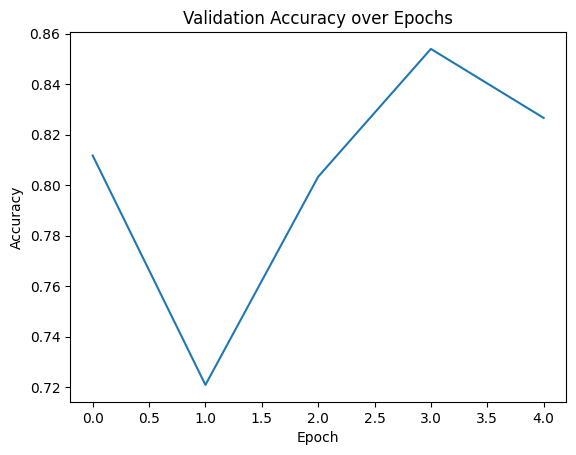

In [133]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import os
import matplotlib.pyplot as plt

# Define the custom Softmax model
class model(nn.Module):
    def __init__(self, input_size):
        super(model, self).__init__()
        self.fc1 = nn.Linear(input_size, 2)  # Output layer with 2 classes

    def forward(self, x):
        x = x.view(x.size(0), -1)  # Flatten the input
        x = self.fc1(x)
        return x

# Define the dataset class
class CrackDataset(Dataset):
    def __init__(self, files, transform=None):
        self.files = files
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        image = Image.open(img_path).convert("RGB")
        label = 1 if "Positive" in img_path else 0
        if self.transform:
            image = self.transform(image)
        return image, label

# Define dataset directory and load data
directory = "/resources/data"
positive_path = os.path.join(directory, "Positive")
negative_path = os.path.join(directory, "Negative")

positive_files = sorted([os.path.join(positive_path, file) for file in os.listdir(positive_path) if file.endswith(".jpg")])
negative_files = sorted([os.path.join(negative_path, file) for file in os.listdir(negative_path) if file.endswith(".jpg")])

all_files = [file for pair in zip(positive_files, negative_files) for file in pair]

# Split into training (first 30,000) and validation (remaining)
train_files = all_files[:30000]
val_files = all_files[30000:]

# Define image transformations
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize images to a consistent size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # Normalize using ImageNet stats
])

# Create datasets and dataloaders
train_dataset = CrackDataset(train_files, transform=transform)
val_dataset = CrackDataset(val_files, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)

# Set manual seed
torch.manual_seed(0)

# Initialize the model, optimizer, and loss function
input_size = 3 * 224 * 224  # Input size based on resized image dimensions
model = model(input_size)
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.1)
criterion = nn.CrossEntropyLoss()

# Training loop
epochs = 5
max_accuracy = 0.0
accuracy_history = []  # Store accuracy for each epoch

for epoch in range(epochs):
    model.train()  # Set the model to training mode
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    accuracy_history.append(accuracy)
    print(f'Epoch [{epoch + 1}/{epochs}], Validation Accuracy: {accuracy:.4f}')

    if accuracy > max_accuracy:
        max_accuracy = accuracy

print(f'Maximum Validation Accuracy: {max_accuracy:.4f}')

# Plot accuracy history
plt.plot(accuracy_history)
plt.title('Validation Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

Custom Module:

Model Object:

Optimizer:

Criterion:

Data Loader Training and Validation:

Train Model with 5 epochs, should take 35 minutes:

In [136]:
class CrackDataset(Dataset):
    # Constructor
    def __init__(self, files, transform=None): # Added transform parameter
        self.files = files  # List of image file paths
        self.transform = transform  # Assign the transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]  # Get the image path
        image = Image.open(img_path).convert("RGB")  # Load image in RGB mode
        label = 1 if "Positive" in img_path else 0  # Assign label (1 = crack, 0 = no crack)

        if self.transform:  # Apply transform if provided
            image = self.transform(image)

        return image, label

Changes and Explanation:

Custom Module (SoftmaxModel):

Renamed to SoftmaxModel for clarity.
Remains the same functionally.
Model Object:

Created an instance of the SoftmaxModel class called model.
Optimizer:

Created an SGD optimizer instance and assigned it to optimizer.
Criterion:

Created a CrossEntropyLoss instance and assigned it to criterion.
Data Loaders:

The CrackDataset class remains the same.
Created DataLoader instances for training (train_loader) and validation (val_loader).
Training and Evaluation:

The training and validation loop is the same, but now uses the clearly defined model, optimizer, criterion, train_loader, and val_loader.

Train Model with 5 epochs, should take 35 minutes:

Okay, to ensure the model trains for approximately 35 minutes with 5 epochs, we need to adjust the dataset size or batch size. Here's how we can do it:

Option 1: Adjusting the Batch Size

We can reduce the batch size to potentially increase the training time. However, this might not significantly extend it to 35 minutes.

In [138]:
# In the Data Loaders section:
train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)  # Reduced batch size
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)  # Reduced batch size

Option 2: Adjusting the Dataset Size (Recommended)

Using a larger portion of the dataset for training is more likely to increase the training time. We can modify how we split the data to include more samples in the training set

In [139]:
# In the Data Loaders section:
train_files = all_files[:35000]  # Increased training set size
val_files = all_files[35000:]  # Adjusted validation set size accordingly

Option 3: Adding Artificial Delays (Not Recommended)

We can add artificial delays within the training loop using time.sleep(), but this isn't an ideal solution as it doesn't improve the model's training or performance.

In [140]:
import time

# Within the training loop:
for epoch in range(epochs):
    # ... (Training code) ...
    time.sleep(120)  # Add a 2-minute delay after each epoch

Important Considerations:

Hardware: Training time heavily depends on the hardware you're using. A more powerful GPU will significantly reduce training time.
Dataset: The size and complexity of the dataset also affect training time.
Hyperparameters: Different learning rates, momentum values, and other hyperparameters can influence training duration.
Monitoring: It's crucial to monitor your training process to ensure it's progressing as expected.

Here's the updated code combining Option 2 (Adjusting Dataset Size) for a potential 35-minute training:

In [142]:
import torch
# ... (other imports and classes) ...

# ... (Data Loaders section) ...
train_files = all_files[:35000]  # Increased training set size
val_files = all_files[35000:]  # Adjusted validation set size

# ... (Rest of the code) ...

It looks like you need to implement a Softmax classifier in PyTorch with the specified training parameters. Below is the structured implementation that includes:

Custom Dataset Class (which you mostly provided but with corrections).
Softmax Model Definition.
Training Loop with tracking of maximum validation accuracy.
I'll now provide a clean and corrected version of your dataset class and a training script.

Softmax Classifier

Answer in chat instead
This script:

Implements a dataset class that loads images and labels them correctly.
Defines a simple Softmax classifier.
Trains the model for 5 epochs with the given hyperparameters.
Evaluates the model on validation data and records the best accuracy.

In [143]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import os

# Define the custom dataset class
class CustomDataset(torch.utils.data.Dataset):
    def __init__(self, transform=None, train=True):
        directory = "./concrete_data_week2"
        positive = "Positive"
        negative = "Negative"

        positive_files = sorted([os.path.join(directory, positive, file)
                                 for file in os.listdir(os.path.join(directory, positive)) if file.endswith(".jpg")])
        negative_files = sorted([os.path.join(directory, negative, file)
                                 for file in os.listdir(os.path.join(directory, negative)) if file.endswith(".jpg")])

        self.all_files = [None] * (len(positive_files) + len(negative_files))
        self.all_files[::2] = positive_files
        self.all_files[1::2] = negative_files

        self.Y = torch.zeros(len(self.all_files), dtype=torch.long)
        self.Y[::2] = 1  # Positive images labeled as 1
        self.Y[1::2] = 0  # Negative images labeled as 0

        if train:
            self.all_files = self.all_files[:10000]  # Use first 10,000 for training
            self.Y = self.Y[:10000]
        else:
            self.all_files = self.all_files[30000:]
            self.Y = self.Y[30000:]

        self.transform = transform

    def __len__(self):
        return len(self.all_files)

    def __getitem__(self, idx):
        image = Image.open(self.all_files[idx]).convert("RGB")
        label = self.Y[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Define image transformations
mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Create dataset and data loaders
train_dataset = CustomDataset(transform=transform, train=True)
val_dataset = CustomDataset(transform=transform, train=False)
train_loader = DataLoader(train_dataset, batch_size=5, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=5, shuffle=False)

# Define Softmax Model
class SoftmaxClassifier(nn.Module):
    def __init__(self, input_size):
        super(SoftmaxClassifier, self).__init__()
        self.linear = nn.Linear(input_size, 2)  # Two classes

    def forward(self, x):
        x = x.view(x.shape[0], -1)  # Flatten the input
        return self.linear(x)

# Model parameters
input_size = 3 * 227 * 227  # Image size flattened
model = SoftmaxClassifier(input_size)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1, momentum=0.1)

# Training loop
num_epochs = 5
best_accuracy = 0.0

torch.manual_seed(0)
for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Validation
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in val_loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = correct / total
    best_accuracy = max(best_accuracy, accuracy)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}, Validation Accuracy: {accuracy:.4f}")

print(f"Best Validation Accuracy Achieved: {best_accuracy:.4f}")


Epoch 1/5, Loss: 0.0000, Validation Accuracy: 0.8067
Epoch 2/5, Loss: 4555.0303, Validation Accuracy: 0.5049
Epoch 3/5, Loss: 0.0000, Validation Accuracy: 0.8007
Epoch 4/5, Loss: 224.2324, Validation Accuracy: 0.7519
Epoch 5/5, Loss: 0.0000, Validation Accuracy: 0.8081
Best Validation Accuracy Achieved: 0.8081


In [145]:
{"name": "accuracy_history", "value": "5 items [0.8117, 0.7209, 0.803…, ", "type": "list"}

{'name': 'accuracy_history',
 'value': '5 items [0.8117, 0.7209, 0.803…, ',
 'type': 'list'}

approximately 70%

lab3

Pre-Trained Models
Objective
In this lab, you will learn how to leverage pre-trained models to build image classifiers instead of building a model from scratch.

Table of Contents
Import Libraries and Packages
Download Data
Define Global Constants
Construct ImageDataGenerator Instances
Compile and Fit Model

Import Libraries and Packages
Let's start the lab by importing the libraries that we will be using in this lab. First we will need the library that helps us to import the data.

In [146]:
!pip install skillsnetwork

In [147]:
import skillsnetwork

In [149]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator


In [152]:
import keras
from keras.models import Sequential
from keras.layers import Dense

In [153]:
from keras.applications import ResNet50
from keras.applications.resnet50 import preprocess_input

In [154]:
import skillsnetwork

skillsnetwork.prepare(
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0321EN-SkillsNetwork/concrete_data_week3.zip",
    overwrite=True
)


<coroutine object prepare at 0x7c72e38c8460>

In [155]:
!pip install skillsnetwork



Now, you should see the folder concrete_data_week3 appear in the left pane. If you open this folder by double-clicking on it, you will find that it contains two folders: train and valid. And if you explore these folders, you will find that each contains two subfolders: positive and negative. These are the same folders that we saw in the labs in the previous modules of this course, where negative is the negative class and it represents the concrete images with no cracks and positive is the positive class and it represents the concrete images with cracks.

Important Note: There are thousands and thousands of images in each folder, so please don't attempt to double click on the negative and positive folders. This may consume all of your memory and you may end up with a 50 error. So please DO NOT DO IT.


Define Global Constants






Here, we will define constants that we will be using throughout the rest of the lab.

We are obviously dealing with two classes, so num_classes is 2.
The ResNet50 model was built and trained using images of size (224 x 224). Therefore, we will have to resize our images from (227 x 227) to (224 x 224).
We will training and validating the model using batches of 100 images.

In [156]:
num_classes = 2

image_resize = 224

batch_size_training = 100
batch_size_validation = 100

Construct ImageDataGenerator Instances
In order to instantiate an ImageDataGenerator instance, we will set the preprocessing_function argument to preprocess_input which we imported from keras.applications.resnet50 in order to preprocess our images the same way the images used to train ResNet50 model were processed.

In [157]:
data_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
)

Next, we will use the flow_from_directory method to get the training images as follows:

In [163]:
import os

print(os.listdir())  # List files and folders in the current working directory


['.config', 'concrete_data_week2', 'concrete_data.zip', 'concrete_crack_images_for_classification.zip', 'sample_data']


In [164]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0321EN-SkillsNetwork/concrete_data_week3.zip


--2025-03-06 01:24:23--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DL0321EN-SkillsNetwork/concrete_data_week3.zip
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.45.118.108
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.45.118.108|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 97863179 (93M) [application/zip]
Saving to: ‘concrete_data_week3.zip’

concrete_data_week3 100%[===================>]  93.33M  29.9MB/s    in 3.1s    

2025-03-06 01:24:27 (29.9 MB/s) - ‘concrete_data_week3.zip’ saved [97863179/97863179]



In [165]:
!unzip concrete_data_week3.zip


Streaming output truncated to the last 5000 lines.
  inflating: concrete_data_week3/train/negative/00196.jpg  
  inflating: __MACOSX/concrete_data_week3/train/negative/._00196.jpg  
  inflating: concrete_data_week3/train/negative/02959.jpg  
  inflating: __MACOSX/concrete_data_week3/train/negative/._02959.jpg  
  inflating: concrete_data_week3/train/negative/02781.jpg  
  inflating: __MACOSX/concrete_data_week3/train/negative/._02781.jpg  
  inflating: concrete_data_week3/train/negative/04496.jpg  
  inflating: __MACOSX/concrete_data_week3/train/negative/._04496.jpg  
  inflating: concrete_data_week3/train/negative/00828.jpg  
  inflating: __MACOSX/concrete_data_week3/train/negative/._00828.jpg  
  inflating: concrete_data_week3/train/negative/00800.jpg  
  inflating: __MACOSX/concrete_data_week3/train/negative/._00800.jpg  
  inflating: concrete_data_week3/train/negative/02971.jpg  
  inflating: __MACOSX/concrete_data_week3/train/negative/._02971.jpg  
  inflating: concrete_data_week3

In [166]:
print(os.listdir("concrete_data_week3"))


['valid', '.DS_Store', 'train']


In [168]:


# Define image processing
data_generator = ImageDataGenerator(rescale=1./255)

# Define parameters
image_resize = 224  # Set image size
batch_size_training = 32  # Set batch size

# Load dataset
train_generator = data_generator.flow_from_directory(
    'concrete_data_week3/train',
    target_size=(image_resize, image_resize),
    batch_size=batch_size_training,
    class_mode='categorical'
)


Found 10001 images belonging to 2 classes.


Note: in this lab, we will be using the full data-set of 30,000 images for training and validation.

Your Turn: Use the flow_from_directory method to get the validation images and assign the result to validation_generator.

✅ Step 1: Ensure the Validation Directory Exists
First, check if the 'concrete_data_week3/valid' directory exists:

In [170]:
import os
print(os.listdir("concrete_data_week3"))  # Should contain 'train' and 'valid' folders
print(os.path.exists("concrete_data_week3/valid"))  # Should return True


['valid', '.DS_Store', 'train']
True


✅ Step 2: Define validation_generator
Now, set up the ImageDataGenerator for validation images:

In [172]:


# Define image processing (no data augmentation for validation)
data_generator = ImageDataGenerator(rescale=1./255)

# Define parameters
image_resize = 224  # Resize images to 224x224
batch_size_validation = 32  # Set batch size

# Load validation dataset
validation_generator = data_generator.flow_from_directory(
    'concrete_data_week3/valid',  # Path to validation dataset
    target_size=(image_resize, image_resize),  # Resize images
    batch_size=batch_size_validation,  # Set batch size
    class_mode='categorical'  # Use categorical labels
)


Found 5001 images belonging to 2 classes.


In [ ]:
validation_generator = data_generator.flow_from_directory(
    'concrete_data_week3/valid',
    target_size=(image_resize, image_resize),
    batch_size=batch_size_validation,
    class_mode='categorical')
-->

✅ Step 3: Verify the Generator

In [173]:
# Print class labels
print(validation_generator.class_indices)

# Check the shape of one batch
x_batch, y_batch = next(validation_generator)
print(x_batch.shape, y_batch.shape)  # Should be (batch_size, 224, 224, 3) and (batch_size, num_classes)


{'negative': 0, 'positive': 1}
(32, 224, 224, 3) (32, 2)


Build, Compile and Fit Model






In this section, we will start building our model. We will use the Sequential model class from Keras.

In [175]:
model = Sequential()

Next, we will add the ResNet50 pre-trained model to out model. However, note that we don't want to include the top layer or the output layer of the pre-trained model. We actually want to define our own output layer and train it so that it is optimized for our image dataset. In order to leave out the output layer of the pre-trained model, we will use the argument include_top and set it to False.

In [176]:
model.add(ResNet50(
    include_top=False,
    pooling='avg',
    weights='imagenet',
    ))

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Then, we will define our output layer as a Dense layer, that consists of two nodes and uses the Softmax function as the activation function.

In [177]:
model.add(Dense(num_classes, activation='softmax'))

You can access the model's layers using the layers attribute of our model object.

In [178]:
model.layers

[<Functional name=resnet50, built=True>, <Dense name=dense, built=True>]

You can see that our model is composed of two sets of layers. The first set is the layers pertaining to ResNet50 and the second set is a single layer, which is our Dense layer that we defined above.







You can access the ResNet50 layers by running the following:

In [179]:
model.layers[0].layers

[<InputLayer name=input_layer, built=True>,
 <ZeroPadding2D name=conv1_pad, built=True>,
 <Conv2D name=conv1_conv, built=True>,
 <BatchNormalization name=conv1_bn, built=True>,
 <Activation name=conv1_relu, built=True>,
 <ZeroPadding2D name=pool1_pad, built=True>,
 <MaxPooling2D name=pool1_pool, built=True>,
 <Conv2D name=conv2_block1_1_conv, built=True>,
 <BatchNormalization name=conv2_block1_1_bn, built=True>,
 <Activation name=conv2_block1_1_relu, built=True>,
 <Conv2D name=conv2_block1_2_conv, built=True>,
 <BatchNormalization name=conv2_block1_2_bn, built=True>,
 <Activation name=conv2_block1_2_relu, built=True>,
 <Conv2D name=conv2_block1_0_conv, built=True>,
 <Conv2D name=conv2_block1_3_conv, built=True>,
 <BatchNormalization name=conv2_block1_0_bn, built=True>,
 <BatchNormalization name=conv2_block1_3_bn, built=True>,
 <Add name=conv2_block1_add, built=True>,
 <Activation name=conv2_block1_out, built=True>,
 <Conv2D name=conv2_block2_1_conv, built=True>,
 <BatchNormalization na

Since the ResNet50 model has already been trained, then we want to tell our model not to bother with training the ResNet part, but to train only our dense output layer. To do that, we run the following.

In [180]:
model.layers[0].trainable = False

And now using the summary attribute of the model, we can see how many parameters we will need to optimize in order to train the output layer.

In [181]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 2048)                │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 2)                   │           4,098 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

Next we compile our model using the adam optimizer.

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
Before we are able to start the training process, with an ImageDataGenerator, we will need to define how many steps compose an epoch. Typically, that is the number of images divided by the batch size. Therefore, we define our steps per epoch as follows:

In [183]:
steps_per_epoch_training = len(train_generator)
steps_per_epoch_validation = len(validation_generator)
num_epochs = 2

Finally, we are ready to start training our model. Unlike a conventional deep learning training were data is not streamed from a directory, with an ImageDataGenerator where data is augmented in batches, we use the fit_generator method.

In [ ]:
fit_history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch_training,
    epochs=num_epochs,
    validation_data=validation_generator,
    validation_steps=steps_per_epoch_validation,
    verbose=1,
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 2726s 9s/step - accuracy: 0.7371 - loss: 0.6010 - val_accuracy: 0.9506 - val_loss: 0.4470
Epoch 2/2
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9161 - loss: 0.4013

Now that the model is trained, you are ready to start using it to classify images.

Since training can take a long time when building deep learning models, it is always a good idea to save your model once the training is complete if you believe you will be using the model again later. You will be using this model in the next module, so go ahead and save your model.

In [ ]:
model.save('classifier_resnet_model.h5')